# **Facial Emotion Detection**

## **Problem Definition**

**The context:** Why is this problem important to solve?<br>

 Facial emotion detection is an important topic in the fields of computer vision and artificial intelligence owing to its significant academic and commercial potential.It plays a crucial role in understanding human behavior, improving human-computer interactions, enhancing healthcare and mental health services, and benefiting various industries and domains where emotions play a significant role. It has the potential to contribute to more empathetic, efficient, and personalized solutions in a wide range of applications such as Virtual Reality (VR) and Augmented Reality (AR), Advanced driver assistant systems (ADASs),Gaming and Entertainment, Autism Spectrum Disorder (ASD) Diagnosis, telemedicine and virtual therapy sessions and in applications detects a user is frustrated or anxious or tired etc.Therefore, identifying facial emotions accurately is very important to the development of machines with AI capabilities.

**The objectives:** What is the intended goal?<br>

The goal is to accurately predict facial impotions using deep learning techniques. In this project, we will build a multi-class classification algorithm on images of facial expressions to predict 4 different classes of the Facial Emotions (Happy, Sad, Neutral and Surprise) using Convolutional Neural Networks and Transfer Learning.

**The key questions:** What are the key questions that need to be answered?<br>

1. What is the percentage of classifying images to correct classes?
2. What is the percentage of classifying images to wrong classes?

**The problem formulation:** What are we trying to solve using data science?

Using data science, we are going to identify a deep learning model which will classify images of facial emotions to four classes accurately. Here we will develop a CNN which is capable of identifying unique features of faces in each emotion and learn a model which can be used to predict emotion of the unseen facial images once fed into the model with a higher accuracy.

## **About the dataset**

The data set consists of 3 folders, i.e., 'test', 'train', and 'validation'.
Each of these folders has four subfolders:

**‘happy’**: Images of people who have happy facial expressions.<br>
**‘sad’**: Images of people with sad or upset facial expressions.<br>
**‘surprise’**: Images of people who have shocked or surprised facial expressions.<br>
**‘neutral’**: Images of people showing no prominent emotion in their facial expression at all.<br>


## **Mounting the Drive**

**NOTE:**  Please use Google Colab from your browser for this notebook. **Google.colab is NOT a library that can be downloaded locally on your device.**

In [ ]:
from google.colab import drive
drive.mount('/content/drive')


Mounted at /content/drive


## **Importing the Libraries**

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import zipfile
from PIL import Image
import math

# Importing Deep Learning Libraries

import tensorflow as tf


# Keras Sequential Model
from tensorflow.keras.models import Sequential

from tensorflow.keras.utils import load_img, img_to_array
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Importing all the different layers and optimizers
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization, Activation, LeakyReLU, Conv2D,MaxPooling2D, Flatten
from tensorflow.keras.optimizers import Adam,SGD
from sklearn.utils import class_weight

# The below code can be used to ignore the warnings that may occur due to deprecations
import warnings
warnings.filterwarnings("ignore")

### **Let us load and unzip the data**

In [ ]:
# Storing the path of the data file from the Google drive
path = '/XX/Facial_emotion_images.zip'

# The data is provided as a zip file so we need to extract the files from the zip file
with zipfile.ZipFile(path, 'r') as zip_ref:
    zip_ref.extractall()

## **Visualizing our Classes**

Let's look at our classes.

**Write down your observation for each class. What do you think can be a unique feature of each emotion, that separates it from the remaining classes?**

In [ ]:
picture_size = 48
folder_path = "Facial_emotion_images/"

### **Happy**

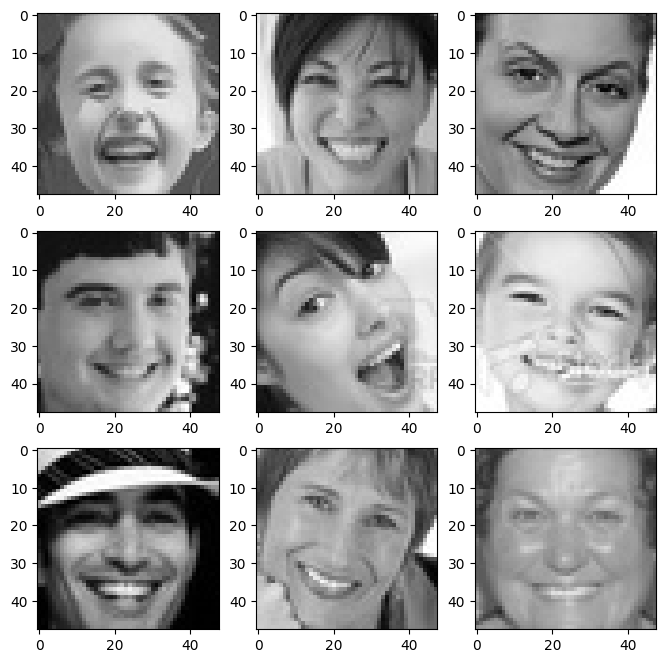

In [ ]:
# Visualizing facial emotion type 'happy' in training set
facial_emotion = 'happy'

plt.figure(figsize = (8, 8))

for i in range(1, 10, 1):
    plt.subplot(3, 3, i)
    img = load_img(folder_path + "train/" + facial_emotion + "/" +
                  os.listdir(folder_path + "train/" + facial_emotion)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:__**


*   All the images are grayscale
*   We can see magnified images of faces of both men and women as well as kids and babies



*   As the images present only the face part, we can identify that smiling feature is common among all the images. Most of the images present open mouth with teeth as well as muscle changes around mouth forming wrincles. We can assume that those unique features can be used to distinguish this class from others



### **Sad**

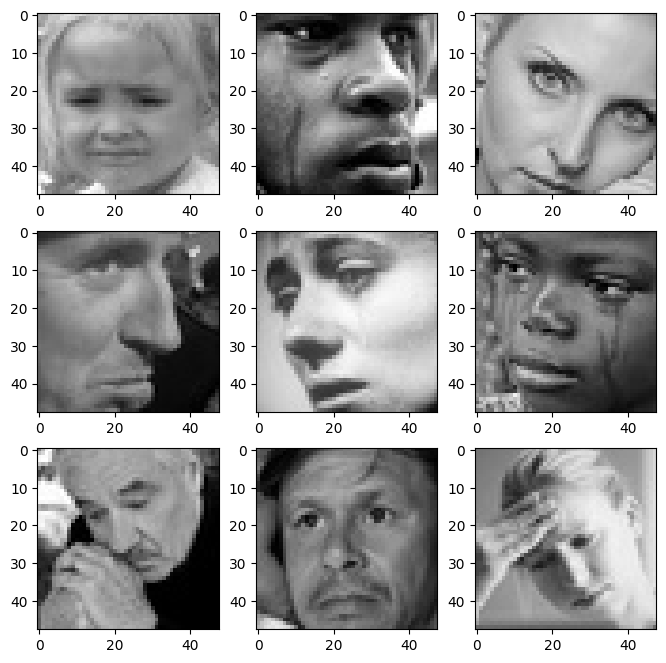

In [ ]:
# Visualizing facial emotion type 'sad' in training set
facial_emotion = 'sad'

plt.figure(figsize = (8, 8))

for i in range(1, 10, 1):
    plt.subplot(3, 3, i)
    img = load_img(folder_path + "train/" + facial_emotion + "/" +
                  os.listdir(folder_path + "train/" + facial_emotion)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:__**
*   All the images are grayscale
*   This dataset also present only face part of men, women and kids and babies.
* Some images are present with crying with tears.  

*   Many images show that a hand is present supporting the angle of the face and therefore we can assume that the shape of eyes and eyebrows along with shape of muscles around mouth distinguish sad emotion from other classes.

### **Neutral**

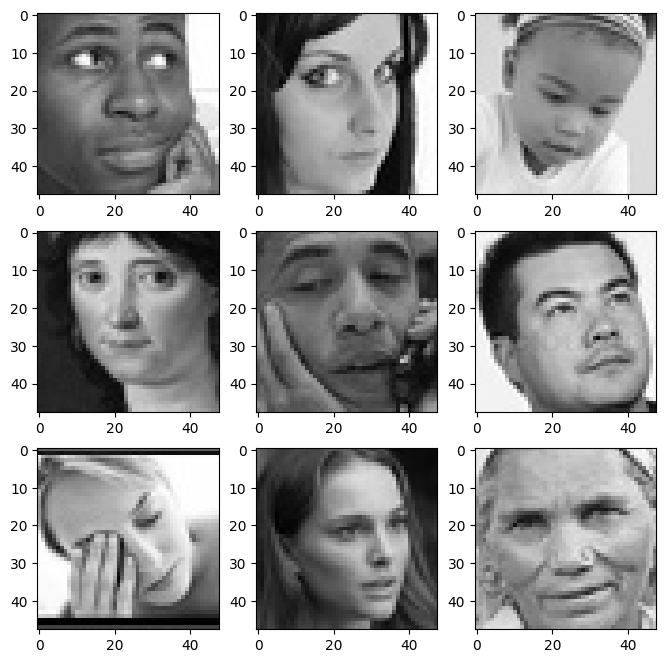

In [ ]:
# Visualizing facial emotion type 'neutral' in training set
facial_emotion = 'neutral'

plt.figure(figsize = (8, 8))

for i in range(1, 10, 1):
    plt.subplot(3, 3, i)
    img = load_img(folder_path + "train/" + facial_emotion + "/" +
                  os.listdir(folder_path + "train/" + facial_emotion)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:__**
*   All the images are grayscale
*   Here we can see there is no specific emotion expressed in faces. There is no common movement in mouth, eyes, eyebrows or facial
*   Many images show that people are looking some direction without any specific felling.







### **Surprised**

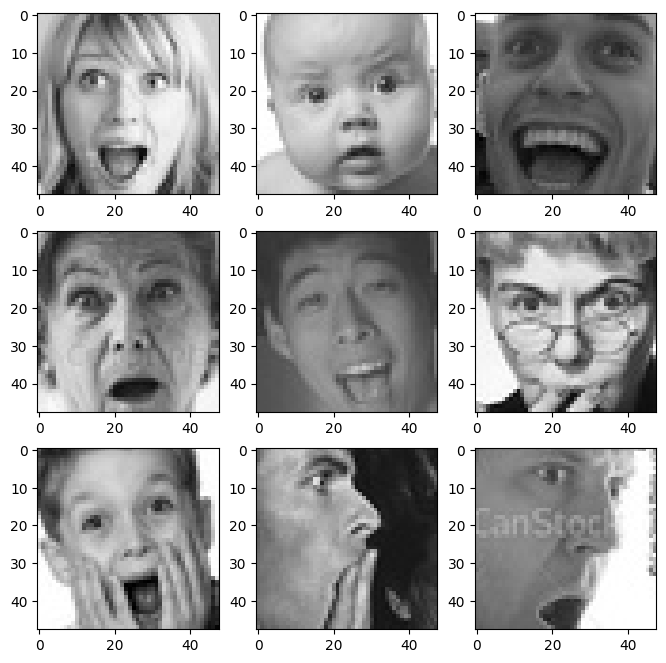

In [ ]:
# Visualizing facial emotion type 'surprise' in training set
facial_emotion = 'surprise'

plt.figure(figsize = (8, 8))

for i in range(1, 10, 1):
    plt.subplot(3, 3, i)
    img = load_img(folder_path + "train/" + facial_emotion + "/" +
                  os.listdir(folder_path + "train/" + facial_emotion)[i], target_size = (picture_size, picture_size))
    plt.imshow(img)

plt.show()

**Observations and Insights:__**
*   All the images are grayscale
*   In here we can see that all images show enlarged eyes, shape of eyebrows expressing the suprise. Some carries movements in mouth also(Jaw dropping feature). Those features will be unique to identify this caterory compared to other classes.






## **Checking Distribution of Classes**

Images in each sub folder in training dataset 
happy:  3976 
sad:  3982 
neutral:  3978 
surprise:  3173


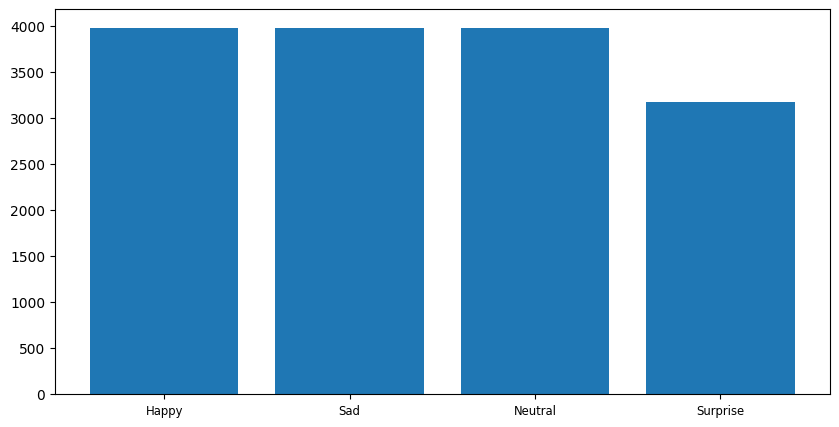

In [ ]:
#Number of images in happy sub folder in train dataset
happy_count = len(os.listdir(folder_path + "train/happy"))

#Number of images in sad sub folder in train dataset
sad_count = len(os.listdir(folder_path + "train/sad"))

#Number of images in neutral sub folder in train dataset
neutral_count = len(os.listdir(folder_path + "train/neutral"))

#Number of images in surprise sub folder in train dataset
surprise_count = len(os.listdir(folder_path + "train/surprise"))

print('Images in each sub folder in training dataset', '\nhappy: ',happy_count,
      '\nsad: ',sad_count,'\nneutral: ',neutral_count,'\nsurprise: ',surprise_count)

train_count = {'Happy': happy_count, 'Sad': sad_count, 'Neutral': neutral_count, 'Surprise': surprise_count}

data = pd.Series(train_count)

# Plotting the histogram
plt.figure(figsize = (10, 5))

plt.bar(range(len(data)), data.values, align = 'center')

plt.xticks(range(len(data)), data.index.values, size = 'small')

plt.show()



**Observations and Insights:__**



*   There are four classes available in this data set namely 'happy, sad, surprise and neutral
*  Images in each subfolder are happy:  3976, sad:  3982, neutral:  3978 and surprise:  3173 in training set
*   Number of images present in all the classes are not perfectly equally distributed as suprise class having little less number of images compared to other classes.
*   The class imbalance in the dataset is not extreme, but it is still noticeable. As the class imbalance can impact the performance of machine learning models we will use data augmentation techniques to artificially increase the number of samples in the dataset, which can help mitigate class imbalance.



**Distribution of validation dataset**

Images in each sub folder in validation dataset 
happy:  1825 
sad:  1139 
neutral:  1216 
surprise:  797


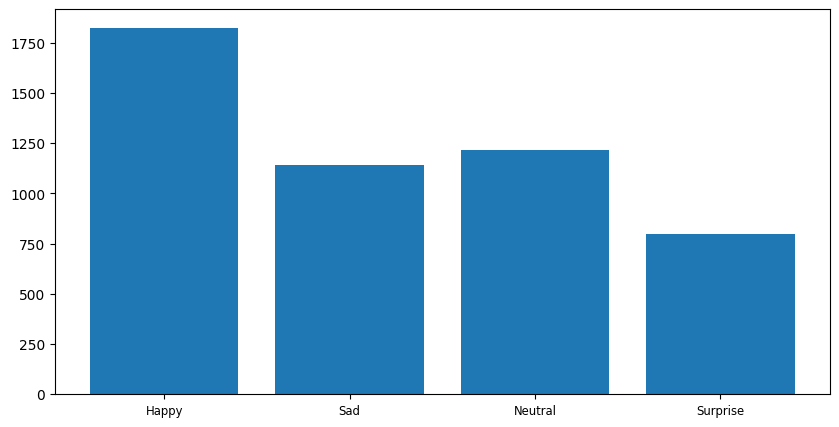

In [ ]:
#Number of images in happy sub folder in validation dataset
happy_count = len(os.listdir(folder_path + "validation/happy"))

#Number of images in sad sub folder in validation dataset
sad_count = len(os.listdir(folder_path + "validation/sad"))

#Number of images in neutral sub folder in validation dataset
neutral_count = len(os.listdir(folder_path + "validation/neutral"))

#Number of images in surprise sub folder in validation dataset
surprise_count = len(os.listdir(folder_path + "validation/surprise"))

print('Images in each sub folder in validation dataset', '\nhappy: ',happy_count,
      '\nsad: ',sad_count,'\nneutral: ',neutral_count,'\nsurprise: ',surprise_count)

train_count = {'Happy': happy_count, 'Sad': sad_count, 'Neutral': neutral_count, 'Surprise': surprise_count}

data = pd.Series(train_count)

# Plotting the histogram
plt.figure(figsize = (10, 5))

plt.bar(range(len(data)), data.values, align = 'center')

plt.xticks(range(len(data)), data.index.values, size = 'small')

plt.show()


*   Images in each sub folder in validation dataset is happy:  1825,
sad:  1139, neutral:  1216 and surprise:  797
*    Validation dataset is highly imbalanced and will affect the validation accuracy





**Think About It:**
* Are the classes equally distributed? If not, do you think the imbalance is too high? Will it be a problem as we progress?

  


**Classes are not equally distributed. Surprise class having little less number of images compared to other classes. But that class imbalance is not too high. That can impact the performance of machine learning models as it can lead to model bias, where the model may perform better on the majority class and struggle to correctly classify the minority class. Therefore we will use data augmentation techniques to artificially increase the number of samples in the dataset to mitigate the class imbalance**

* Are there any Exploratory Data Analysis tasks that we can do here? Would they provide any meaningful insights?

**Yes, There are few EDA tasks we can conduct over this already categorized images of four classes that involves gaining a preliminary understanding of the data and its characteristics which will give us some meaningful insights such as size of the dataset, class imbalance, visual characteristics, colour distributions, image similarity etc**

1. Dataset Overview:

Helps to determine the size of the dataset, including the number of images, and the dimensions (e.g., width, height, and channels) of each image and understand the distribution of images among the four categories.

2. Visual Inspection:

Visualizing few random images from each category to get an initial sense of the data. This can help to spot any anomalies or data quality issues.

3. Class Imbalance:

Check for class imbalance by counting the number of samples in each category. As if there's a significant imbalance, it may affect model performance.

4. Color Distribution

By analysing colour distribution we got to know that the dataset is consisting of grayscale images.

5. Data Augmentation
As there is class inbalance present we can apply data augmentation techniques to create additional training data, such as rotation, flipping, or zooming, to help improve model generalization

## **Creating our Data Loaders**

In this section, we are creating data loaders that we will use as inputs to our Neural Network.

**You have two options for the color_mode. You can set it to color_mode = 'rgb' or color_mode = 'grayscale'. You will need to try out both and see for yourself which one gives better performance.**

In [ ]:
#data loaders with color_mode = 'grayscale'
batch_size  = 128

#image generators with normalization and data augmentation
datagen_train  = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)
datagen_val = ImageDataGenerator(rescale=1./255)
datagen_test = ImageDataGenerator(rescale=1./255)

train_set = datagen_train.flow_from_directory(folder_path + 'train/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "grayscale",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

validation_set = datagen_val.flow_from_directory(folder_path + 'validation/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "grayscale",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

test_set = datagen_test.flow_from_directory(folder_path + 'test/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "grayscale",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


In [ ]:
#data loaders with color_mode = 'rgb'
batch_size  = 128

train_set_rgb = datagen_train.flow_from_directory(folder_path + 'train/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "rgb",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

validation_set_rgb = datagen_val.flow_from_directory(folder_path + 'validation/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "rgb",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

test_set_rgb = datagen_test.flow_from_directory(folder_path + 'test/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "rgb",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


 **Observations_**

1. There are four classes available in this data set namely 'happy, sad, surprise and neutral
2. Images in each subfolder are happy: 3976, sad: 3982, neutral: 3978 and surprise: 3173 in training set
3. Thereare 15109 images in training set, 4977 images in validation set and 128 images in testing set.

## **Model Building**

**Think About It:**
* Are Convolutional Neural Networks the right approach? Should we have gone with Artificial Neural Networks instead?

**Yes. CNN is the right approach as here we are going to identify facial emotions present in images. CNNs are specifically designed to recognize spatial hierarchies and local patterns in images. They use convolutional layers to apply filters that capture features like edges, textures, and shapes at different spatial scales. ANNs, on the other hand, treat input data as a flattened vector, losing the spatial information present in images. Here we classify images into different emotions based on specific features present in the images therefore CNN is the best solution.**


* What are the advantages of CNNs over ANNs and are they applicable here?


1.   **Ability to identify Spatial Hierarchies and Local Patterns**
2.   **Translation Invariance(CNN can recognize patterns regardless of where they appear in the image)**
3. **Layer Architecture: CNNs are typically composed of alternating convolutional and pooling layers followed by fully connected layers. This architecture is well-suited for image data. ANNs have a more generic architecture, making them less specialized for image processing.**
4. **Reduced Overfitting: CNNs tend to generalize better to new, unseen images, thanks to techniques like dropout and weight regularization that help reduce overfitting. ANNs may struggle with overfitting when dealing with high-dimensional image data.**



# **Creating the Base Neural Network**

##**For Gray Scale colour mode**

In [ ]:
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Using grayscale colour mode
# Here a simple model is created without any batch normalization or dropout layers
from keras.src.backend import relu
model1 = Sequential()

# First Convolutional Layer
model1.add(Conv2D(64, (3, 3), activation = "relu", input_shape = (48, 48, 1), padding = 'same'))
model1.add(MaxPooling2D(2, 2))

# Second Convolutional Layer
model1.add(Conv2D(32, (3, 3),activation = "relu", padding = 'same'))
model1.add(MaxPooling2D(2, 2))

# Third Convolutional Layer
model1.add(Conv2D(128, (3, 3), activation = "relu", padding = 'same'))
model1.add(MaxPooling2D(2,2))

# Fourth Convolutional Layer
model1.add(Conv2D(256, (3, 3), activation = "relu", padding = 'same'))
model1.add(MaxPooling2D(2, 2))

model1.add(Flatten())

# Fully Connected Layer
model1.add(Dense(512 ,activation = "relu"))


# Classifier
model1.add(Dense(4, activation = 'softmax'))



### **Compiling and Training the Model**

In [ ]:
#Compile the model with the loss equal to categorical_crossentropy, optimizer equal to Adam(learning_rate = 0.001), and metric equal to 'accuracy'.
optimizer = tf.keras.optimizers.Adam(0.001)
model1.compile(loss='categorical_crossentropy',
              optimizer = optimizer,
              metrics=['accuracy'])

In [ ]:
# Printing out the model1 summary
model1.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_4 (Conv2D)           (None, 48, 48, 64)        640       
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 24, 24, 64)        0         
 g2D)                                                            
                                                                 
 conv2d_5 (Conv2D)           (None, 24, 24, 32)        18464     
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 12, 12, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 12, 12, 128)       36992     
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 6, 6, 128)        

In [ ]:
# Define class weights to address class imbalance
#class_weights = class_weight.compute_class_weight('balanced', np.unique(train_set), train_set)
#Since this task is more time consuming I have ignored.

In [ ]:
#history_1 = model1.fit(train_set, validation_data = validation_set, epochs = 30, class_weight=class_weights)
history_1 = model1.fit(train_set, validation_data = validation_set, epochs = 30)

Epoch 1/30
119/119 [==============================] - 22s 132ms/step - loss: 1.3826 - accuracy: 0.2626 - val_loss: 1.3624 - val_accuracy: 0.3749
Epoch 2/30
119/119 [==============================] - 16s 131ms/step - loss: 1.3030 - accuracy: 0.3561 - val_loss: 1.1918 - val_accuracy: 0.4935
Epoch 3/30
119/119 [==============================] - 15s 128ms/step - loss: 1.1211 - accuracy: 0.4968 - val_loss: 1.0217 - val_accuracy: 0.5664
Epoch 4/30
119/119 [==============================] - 17s 139ms/step - loss: 1.0147 - accuracy: 0.5542 - val_loss: 1.0110 - val_accuracy: 0.5479
Epoch 5/30
119/119 [==============================] - 17s 140ms/step - loss: 0.9588 - accuracy: 0.5837 - val_loss: 0.9039 - val_accuracy: 0.6251
Epoch 6/30
119/119 [==============================] - 15s 129ms/step - loss: 0.9099 - accuracy: 0.6104 - val_loss: 0.8367 - val_accuracy: 0.6474
Epoch 7/30
119/119 [==============================] - 15s 127ms/step - loss: 0.8609 - accuracy: 0.6300 - val_loss: 0.8266 - val_ac

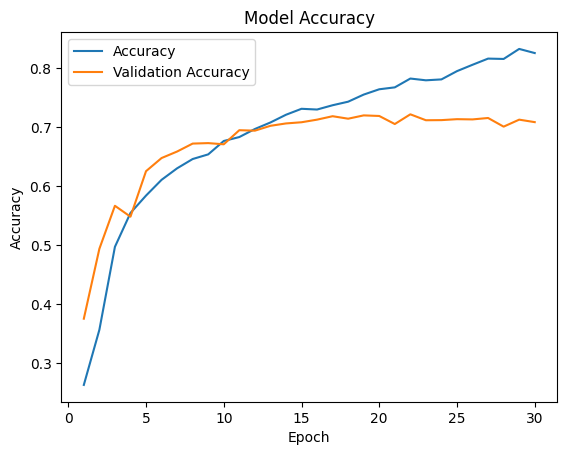

In [ ]:
#Plot the Training and Validation Accuracies for model_1.
list_ep = [i for i in range(1, 31)]
plt.plot(list_ep,history_1.history['accuracy'])
plt.plot(list_ep,history_1.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Accuracy', 'Validation Accuracy'], loc='upper left')
plt.show()

### **Evaluating the Model on the Test Set**

In [ ]:
#for grayscale images
test_images1, test_labels1 = next(test_set)
accuracy = model1.evaluate(test_images1, test_labels1, verbose = 2)

4/4 - 0s - loss: 0.5733 - accuracy: 0.7969 - 33ms/epoch - 8ms/step


##**For RGB colour mode**

In [ ]:
# Clearing backend (previous model's history )
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Above same model is follwed with rgb colour mode
from keras.src.backend import relu
model1_rgb = Sequential()

# First Convolutional Layer
model1_rgb.add(Conv2D(64, (3, 3), activation = "relu", input_shape = (48, 48, 3), padding = 'same'))
model1_rgb.add(MaxPooling2D(2, 2))

# Second Convolutional Layer
model1_rgb.add(Conv2D(32, (3, 3),activation = "relu", padding = 'same'))
model1_rgb.add(MaxPooling2D(2, 2))

# Third Convolutional Layer
model1_rgb.add(Conv2D(128, (3, 3), activation = "relu", padding = 'same'))
model1_rgb.add(MaxPooling2D(2,2))

# Fourth Convolutional Layer
model1_rgb.add(Conv2D(256, (3, 3), activation = "relu", padding = 'same'))
model1_rgb.add(MaxPooling2D(2, 2))

model1_rgb.add(Flatten())

# Fully Connected Layer
model1_rgb.add(Dense(512 ,activation = "relu"))


# Classifier
model1_rgb.add(Dense(4, activation = 'softmax'))

### **Compiling and Training the Model**

In [ ]:
# for model1_rgb
optimizer = tf.keras.optimizers.Adam(0.001)
model1_rgb.compile(loss='categorical_crossentropy',
              optimizer = optimizer,
              metrics=['accuracy'])

In [ ]:
# Printing out the model1_rgb summary
model1_rgb.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 64)        1792      
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 64)        0         
 D)                                                              
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 32)        18464     
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 12, 12, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_2 (Conv2D)           (None, 12, 12, 128)       36992     
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 6, 6, 128)         0

In [ ]:
history_2 = model1_rgb.fit(train_set_rgb, validation_data = validation_set_rgb, epochs = 30)

Epoch 1/30
119/119 [==============================] - 33s 240ms/step - loss: 1.3034 - accuracy: 0.3547 - val_loss: 1.1256 - val_accuracy: 0.5110
Epoch 2/30
119/119 [==============================] - 26s 220ms/step - loss: 1.1083 - accuracy: 0.5127 - val_loss: 0.9732 - val_accuracy: 0.5893
Epoch 3/30
119/119 [==============================] - 29s 245ms/step - loss: 1.0125 - accuracy: 0.5552 - val_loss: 0.9240 - val_accuracy: 0.6056
Epoch 4/30
119/119 [==============================] - 30s 251ms/step - loss: 0.9470 - accuracy: 0.5885 - val_loss: 0.9002 - val_accuracy: 0.6136
Epoch 5/30
119/119 [==============================] - 29s 241ms/step - loss: 0.9054 - accuracy: 0.6073 - val_loss: 0.9039 - val_accuracy: 0.6168
Epoch 6/30
119/119 [==============================] - 26s 218ms/step - loss: 0.8805 - accuracy: 0.6200 - val_loss: 0.8211 - val_accuracy: 0.6548
Epoch 7/30
119/119 [==============================] - 30s 250ms/step - loss: 0.8217 - accuracy: 0.6537 - val_loss: 0.7883 - val_ac

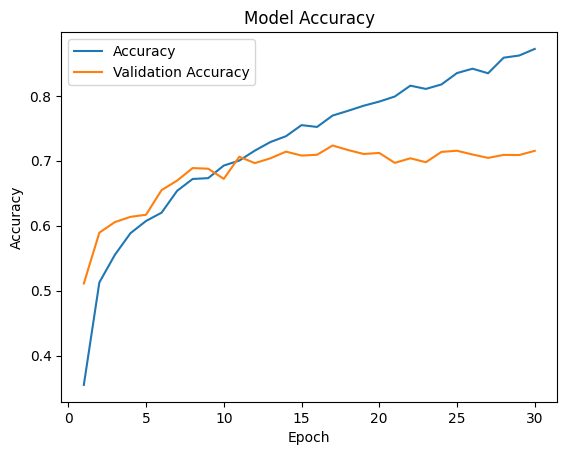

In [ ]:
#Plot the Training and Validation Accuracies for model_1_rgb
list_ep = [i for i in range(1, 31)]
plt.plot(list_ep,history_2.history['accuracy'])
plt.plot(list_ep,history_2.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Accuracy', 'Validation Accuracy'], loc='upper left')
plt.show()

### **Evaluating the Model on the Test Set**


In [ ]:
#for rgb images
test_images1_rgb, test_labels1_rgb = next(test_set_rgb)
accuracy = model1_rgb.evaluate(test_images1_rgb, test_labels1_rgb, verbose = 2)

4/4 - 0s - loss: 0.7597 - accuracy: 0.7812 - 75ms/epoch - 19ms/step


**Observations and Insights:__**
1.   Here we have run the same base CNN model for both grayscale and rgb colour modes with relu activation function , Maxpooling, learning rate of adam = 0.001, loss='categorical_crossentropy' and metric equal to 'accuracy' for 30 epochs
2.   Training accuracy and validation accuracy appears to be ~82% and ~71% in gray scale mode and ~87% and ~71% in rgb mode. Models of both colour modes appears to be overfitting as there is a significant difference between training and validation accuracies.

3. Eventhough we have trained grayscale images, training accuracy and validation accuracy is slightly higher in RGB mode compared to pure grayscale mode in model performance.


*   This may be due to the Model Complexity: Some deep learning models may benefit from the additional complexity introduced by having three color channels. While grayscale images have only one channel, representing them as RGB images provides the model with more input features, potentially enabling it to capture more intricate patterns.


*   Another reason for this behaviour can be Data Variability: When the dataset contains grayscale images but still has variations in terms of lighting, contrast, or texture that can be captured by different color channels, representing them in RGB mode might help the model learn these subtle variations.

4. Test accuracies of models for grayscale colour mode is ~79% and 78% for RGB colour mode. Here it shows that rgb mode and grayscale mode CNN models performs somewhat similar for unseen data.


# **Creating the second Convolutional Neural Network**

- Try out a slightly larger architecture

##**For Gray Scale colour mode**


In [ ]:
# Clearing backend (previous model's history )
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
# Fixing the seed again after clearing the backend
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Using grayscale colour mode
#In this second CNN LeakyRelu activation function is used along with BatchNormalization and Dropout Layers

model2 = Sequential()

# First Convolutional Layer
model2.add(Conv2D(32, (3, 3),  input_shape = (48, 48, 1), padding = 'same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling2D(2, 2))
model2.add(Dropout(0.25))

# Second Convolutional Layer
model2.add(Conv2D(64, (3, 3), padding = 'same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling2D(2, 2))
model2.add(Dropout(0.25))

# Third Convolutional Layer
model2.add(Conv2D(128, (3, 3), padding = 'same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling2D(2,2))


# Fourth Convolutional Layer
model2.add(Conv2D(256, (3, 3), padding = 'same'))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(MaxPooling2D(2, 2))
model2.add(Dropout(0.5))

model2.add(Flatten())

# Fully Connected Layer
model2.add(Dense(512))
model2.add(BatchNormalization())
model2.add(LeakyReLU(0.1))
model2.add(Dropout(0.5))


# Classifier
model2.add(Dense(4, activation = 'softmax'))

### **Compiling and Training the Model**

In [ ]:
#for grayscale colour mode
optimizer = tf.keras.optimizers.Adam(0.001)
model2.compile(loss='categorical_crossentropy',
              optimizer = optimizer,
              metrics=['accuracy'])

In [ ]:
model2.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 32)        320       
                                                                 
 batch_normalization (Batch  (None, 48, 48, 32)        128       
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 48, 48, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 24, 24, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        1

In [ ]:
history_3 = model2.fit(train_set, validation_data = validation_set, epochs = 30)

Epoch 1/30
119/119 [==============================] - 25s 208ms/step - loss: 1.6266 - accuracy: 0.3253 - val_loss: 1.4120 - val_accuracy: 0.2443
Epoch 2/30
119/119 [==============================] - 16s 133ms/step - loss: 1.3179 - accuracy: 0.4262 - val_loss: 1.3155 - val_accuracy: 0.3703
Epoch 3/30
119/119 [==============================] - 16s 136ms/step - loss: 1.1667 - accuracy: 0.4894 - val_loss: 1.4504 - val_accuracy: 0.2134
Epoch 4/30
119/119 [==============================] - 16s 137ms/step - loss: 1.0797 - accuracy: 0.5261 - val_loss: 1.1117 - val_accuracy: 0.5602
Epoch 5/30
119/119 [==============================] - 19s 161ms/step - loss: 1.0297 - accuracy: 0.5514 - val_loss: 0.8761 - val_accuracy: 0.6273
Epoch 6/30
119/119 [==============================] - 22s 181ms/step - loss: 0.9695 - accuracy: 0.5793 - val_loss: 0.8428 - val_accuracy: 0.6530
Epoch 7/30
119/119 [==============================] - 23s 190ms/step - loss: 0.9479 - accuracy: 0.5881 - val_loss: 0.7979 - val_ac

### **Evaluating the Model on the Test Set**

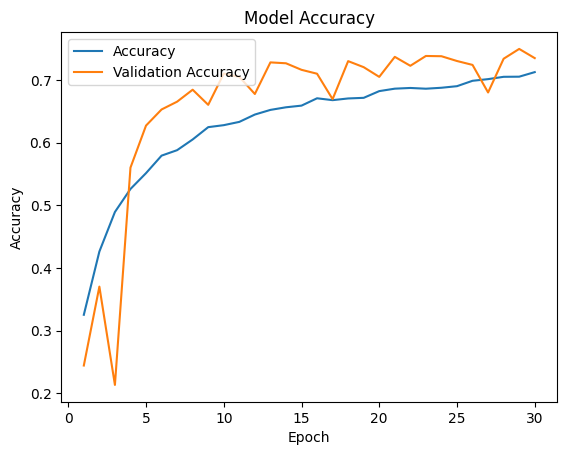

In [ ]:
#Plot the Training and Validation Accuracies for model2
list_ep = [i for i in range(1, 31)]
plt.plot(list_ep,history_3.history['accuracy'])
plt.plot(list_ep,history_3.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Accuracy', 'Validation Accuracy'], loc='upper left')
plt.show()

In [ ]:
#for grayscale images
test_images2, test_labels2 = next(test_set)
accuracy_3 = model2.evaluate(test_images2, test_labels2, verbose = 2)

4/4 - 0s - loss: 0.5441 - accuracy: 0.7812 - 220ms/epoch - 55ms/step


##**For RGB colour mode**


In [ ]:
# Clearing backend (previous model's history )
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
# Fixing the seed again after clearing the backend
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Using rgb colour mode
#In this second CNN LeakyRelu activation function is used along with BatchNormalization and Dropout Layers

 # Intializing a sequential model
model2_rgb = Sequential()

# First Convolutional Layer
model2_rgb.add(Conv2D(32, (3, 3),  input_shape = (48, 48, 3), padding = 'same'))
model2_rgb.add(BatchNormalization())
model2_rgb.add(LeakyReLU(0.1))
model2_rgb.add(MaxPooling2D(2, 2))
model2_rgb.add(Dropout(0.25))

# Second Convolutional Layer
model2_rgb.add(Conv2D(64, (3, 3), padding = 'same'))
model2_rgb.add(BatchNormalization())
model2_rgb.add(LeakyReLU(0.1))
model2_rgb.add(MaxPooling2D(2, 2))
model2_rgb.add(Dropout(0.25))

# Third Convolutional Layer
model2_rgb.add(Conv2D(128, (3, 3), padding = 'same'))
model2_rgb.add(BatchNormalization())
model2_rgb.add(LeakyReLU(0.1))
model2_rgb.add(MaxPooling2D(2,2))


# Fourth Convolutional Layer
model2_rgb.add(Conv2D(256, (3, 3), padding = 'same'))
model2_rgb.add(BatchNormalization())
model2_rgb.add(LeakyReLU(0.1))
model2_rgb.add(MaxPooling2D(2, 2))
model2_rgb.add(Dropout(0.5))

model2_rgb.add(Flatten())

# Fully Connected Layer
model2_rgb.add(Dense(512))
model2_rgb.add(BatchNormalization())
model2_rgb.add(LeakyReLU(0.1))
model2_rgb.add(Dropout(0.5))


# Classifier
model2_rgb.add(Dense(4, activation = 'softmax'))


### **Compiling and Training the Model**


In [ ]:
# for rgb colour mode
optimizer = tf.keras.optimizers.Adam(0.001)
model2_rgb.compile(loss='categorical_crossentropy',
              optimizer = optimizer,
              metrics=['accuracy'])

In [ ]:
model2_rgb.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 32)        896       
                                                                 
 batch_normalization (Batch  (None, 48, 48, 32)        128       
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 48, 48, 32)        0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 32)        0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 24, 24, 32)        0         
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 64)        1

In [ ]:
history_4 = model2_rgb.fit(train_set_rgb, validation_data = validation_set_rgb, epochs = 30)

Epoch 1/30
119/119 [==============================] - 30s 218ms/step - loss: 1.6015 - accuracy: 0.3285 - val_loss: 1.3419 - val_accuracy: 0.3685
Epoch 2/30
119/119 [==============================] - 25s 211ms/step - loss: 1.2962 - accuracy: 0.4343 - val_loss: 1.2773 - val_accuracy: 0.4300
Epoch 3/30
119/119 [==============================] - 27s 227ms/step - loss: 1.1570 - accuracy: 0.4945 - val_loss: 1.2412 - val_accuracy: 0.4079
Epoch 4/30
119/119 [==============================] - 23s 196ms/step - loss: 1.0788 - accuracy: 0.5296 - val_loss: 1.1128 - val_accuracy: 0.5391
Epoch 5/30
119/119 [==============================] - 24s 199ms/step - loss: 1.0354 - accuracy: 0.5463 - val_loss: 1.0527 - val_accuracy: 0.5294
Epoch 6/30
119/119 [==============================] - 28s 233ms/step - loss: 0.9867 - accuracy: 0.5704 - val_loss: 0.8744 - val_accuracy: 0.6337
Epoch 7/30
119/119 [==============================] - 24s 205ms/step - loss: 0.9453 - accuracy: 0.5926 - val_loss: 0.8072 - val_ac

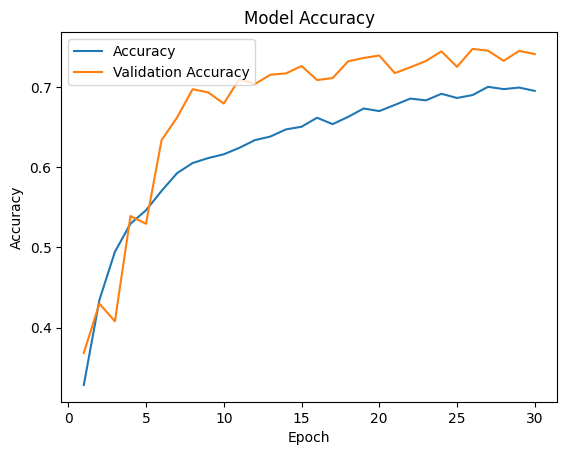

In [ ]:
#Plot the Training and Validation Accuracies for model2_rgb
list_ep = [i for i in range(1, 31)]
plt.plot(list_ep,history_4.history['accuracy'])
plt.plot(list_ep,history_4.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Accuracy', 'Validation Accuracy'], loc='upper left')
plt.show()

### **Evaluating the Model on the Test Set**

In [ ]:
#for rgb images
test_images2_rgb, test_labels2_rgb = next(test_set_rgb)
accuracy_4 = model2_rgb.evaluate(test_images2_rgb, test_labels2_rgb, verbose = 2)

4/4 - 0s - loss: 0.5346 - accuracy: 0.7812 - 91ms/epoch - 23ms/step


**Observations and Insights:__**


1.   Here we have created a slightly larger model architecture with LeakyReLU activation function along with BatchNormalization and Dropout Layers apart from MaxPooling layers which appeared in both base and second CNNs.
2. Training and validation accuracies are as ~71% and ~73% in grayscale mode and ~70% and 74% in RGB scale mode.
3. Both rgb and grayscale mode models appears to perform somewhat similar in this second convolutional model
4.   Here the model performance is somewhat strange as validation accuracy is slightly higher than training accuracy in both grayscale and RGB color mode models.
*   This might occure due to regularization techniques used such as dropout. These techniques introduce randomness and prevent the model from overfitting the training data.
*   Another possible reason is Model Complexity. If the model is very complex and prone to overfitting, it might fit the training data too closely, resulting in lower training accuracy but higher validation accuracy.

4. However test accuracies are as ~78% in both grascale mode and RGB mode which shows there is no significance in color mode whether rgb or grayscale when it come to unseen data.
5. Considering both base and second CNN moedls for grayscale and rgb color modes we can observe that best performance shown by the base CNN model with rgb color mode giving 87% training accuracy, 71% of validation accuracy and 78% of testing accuracy.





## **Think About It:**

* Did the models have a satisfactory performance? If not, then what are the possible reasons?

      Accuracies---->                Trainig | Validation | Test
      
      Base CNN
      Grayscale mode                    82%  |   70%      | 79%
      RGB mode                          87%  |   71%      | 78%

      Second CNN
      Grayscale mode                    71%  |   73%      | 78%
      RGB mode                          70%  |   74%      | 78%

  
  1. Models are showing somewhat satisfactory performance as their training, validation and testing accuracies exceeds 70%.
  2. Base CNN appears to perform better compared to second CNN
  3. RGB colour mode shows a better performance than grayscale mode in both models having 78% of testing accuracy.
  4. Therefore we can consider **base CNN rgb mode** is performing better than other models.
  5. Looking at training and validation accuracy plots we can understand that model appears complex since validation accuracy shows an erratic behavior in second CNN
  6. That may be due to the data augmentation techniques used during training as they can introduce randomness into the training process, leading to variations in model performance on the validation data.
  7. This model complexity might be the reason for this unacceptable behaviour in second CNN of validation accuracy being higher than training accuracy. bold text

* Which Color mode showed better overall performance? What are the possible reasons? Do you think having 'rgb' color mode is needed because the images are already black and white?
  
  **It appears that rgb mode shows a somewhat better overall performance considering all training, validation and test accuracies.**
  
  Possible Reasons:
  1. Model Complexity: Some deep learning models may benefit from the additional complexity introduced by having three color channels. While grayscale images have only one channel, representing them as RGB images provides the model with more input features, potentially enabling it to capture more intricate patterns.


  2. Data Variability: The dataset contains grayscale images but still has variations in terms of lighting, contrast, or texture that can be captured by different color channels, representing them in RGB mode might help the model learn these subtle variations.

  3. Hyperparameter Search: It's possible that the hyperparameters of the model (such as learning rate, batch size, architecture, etc.) are better suited for the RGB representation of grayscale images.

  4. Data Augmentation: We are using data augmentation techniques during training and the added color channels in RGB mode might provide more diversity for the augmented data, potentially helping the model generalize better.

**For this perticular data set I think it is better to have rgb mode as features of the face are better identified due to brightness differences in different parts of the image.**

# **Transfer Learning Architectures**

In this section, we will create several Transfer Learning architectures. For the pre-trained models, we will select three popular architectures namely, VGG16, ResNet v2, and Efficient Net. The difference between these architectures and the previous architectures is that these will require 3 input channels while the earlier ones worked on 'grayscale' images. Therefore, we need to create new DataLoaders.

### **Creating our Data Loaders for Transfer Learning Architectures**

In this section, we are creating data loaders that we will use as inputs to our Neural Network. We will have to go with color_mode = 'rgb' as this is the required format for the transfer learning architectures.

In [ ]:
#data loaders with color_mode = 'rgb'
batch_size  = 128
picture_size = 48

datagen_train  = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)
datagen_val = ImageDataGenerator(rescale=1./255)
datagen_test = ImageDataGenerator(rescale=1./255)
train_set2 = datagen_train.flow_from_directory(folder_path + 'train/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "rgb",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

validation_set2 = datagen_val.flow_from_directory(folder_path + 'validation/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "rgb",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

test_set2 = datagen_test.flow_from_directory(folder_path + 'test/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "rgb",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


## **VGG16 Model**

### **Importing the VGG16 Architecture**

In [ ]:
from tensorflow.keras.applications.vgg16 import VGG16
from tensorflow.keras import Model

vgg = VGG16(include_top = False, weights = 'imagenet', input_shape = (48, 48, 3))
vgg.summary()

58889256/58889256 [==============================] - 0s 0us/step
Model: "vgg16"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 48, 48, 3)]       0         
                                                                 
 block1_conv1 (Conv2D)       (None, 48, 48, 64)        1792      
                                                                 
 block1_conv2 (Conv2D)       (None, 48, 48, 64)        36928     
                                                                 
 block1_pool (MaxPooling2D)  (None, 24, 24, 64)        0         
                                                                 
 block2_conv1 (Conv2D)       (None, 24, 24, 128)       73856     
                                                                 
 block2_conv2 (Conv2D)       (None, 24, 24, 128)       147584    
                                                              

### **Model Building**

- Import VGG16 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
# Clearing backend (previous model's history )
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
# Fixing the seed again after clearing the backend
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Getting only the conv layers for transfer learning.
transfer_layer = vgg.get_layer('block5_pool')
vgg.trainable = False

vgg_model = Sequential()

# Adding the convolutional part of the VGG16 model from above
vgg_model.add(vgg)

# Flattening the output of the VGG16 model because it is from a convolutional layer
vgg_model.add(Flatten())

# Adding a dense output layer
vgg_model.add(Dense(32, activation='relu'))
vgg_model.add(Dropout(0.2))
vgg_model.add(Dense(32, activation='relu'))
vgg_model.add(Dropout(0.2))
vgg_model.add(BatchNormalization())

#classifier
vgg_model.add(Dense(4, activation='softmax'))


### **Compiling and Training the VGG16 Model**

In [ ]:
optimizer = tf.keras.optimizers.Adam(0.001)
vgg_model.compile(optimizer = optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
vgg_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 32)                16416     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 dense_1 (Dense)             (None, 32)                1056      
                                                                 
 dropout_1 (Dropout)         (None, 32)                0         
                                                                 
 batch_normalization (Batch  (None, 32)                1

In [ ]:
## Fitting the VGG model
vgg_model_history = vgg_model.fit(train_set2, validation_data=validation_set2, epochs=20)

Epoch 1/20
119/119 [==============================] - 43s 260ms/step - loss: 1.5009 - accuracy: 0.3164 - val_loss: 1.2372 - val_accuracy: 0.4344
Epoch 2/20
119/119 [==============================] - 28s 235ms/step - loss: 1.3248 - accuracy: 0.3745 - val_loss: 1.1795 - val_accuracy: 0.4671
Epoch 3/20
119/119 [==============================] - 28s 236ms/step - loss: 1.2717 - accuracy: 0.4024 - val_loss: 1.1621 - val_accuracy: 0.4939
Epoch 4/20
119/119 [==============================] - 28s 236ms/step - loss: 1.2434 - accuracy: 0.4201 - val_loss: 1.1345 - val_accuracy: 0.5047
Epoch 5/20
119/119 [==============================] - 29s 247ms/step - loss: 1.2255 - accuracy: 0.4325 - val_loss: 1.1383 - val_accuracy: 0.5005
Epoch 6/20
119/119 [==============================] - 29s 245ms/step - loss: 1.2057 - accuracy: 0.4479 - val_loss: 1.1434 - val_accuracy: 0.4850
Epoch 7/20
119/119 [==============================] - 29s 247ms/step - loss: 1.1994 - accuracy: 0.4537 - val_loss: 1.0999 - val_ac

### **Evaluating the VGG16 model**

In [ ]:
# Evaluating on the Test dataset
accuracy_vgg = vgg_model.evaluate(test_set2)

1/1 [==============================] - 0s 124ms/step - loss: 1.1198 - accuracy: 0.4609


In [ ]:
#Finetuning VGG16 mdoel with increased BtchNormalization, Dropouts and a lower learning rate

In [ ]:
# Clearing backend (previous model's history )
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
# Fixing the seed again after clearing the backend
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [ ]:
# Getting only the conv layers for transfer learning.
transfer_layer = vgg.get_layer('block5_pool')
vgg.trainable = False

vgg_model = Sequential()

# Adding the convolutional part of the VGG16 model from above
vgg_model.add(vgg)

# Flattening the output of the VGG16 model because it is from a convolutional layer
vgg_model.add(Flatten())

# Adding a dense output layer
vgg_model.add(Dense(32, activation='relu'))
vgg_model.add(Dropout(0.25))

vgg_model.add(BatchNormalization())

vgg_model.add(Dense(32, activation='relu'))
vgg_model.add(Dropout(0.25))

vgg_model.add(BatchNormalization())

#classifier
vgg_model.add(Dense(4, activation='softmax'))


In [ ]:
optimizer = tf.keras.optimizers.Adam(0.0001)
vgg_model.compile(optimizer = optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
vgg_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 32)                16416     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 batch_normalization (Batch  (None, 32)                128       
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 32)                1056      
                                                        

In [ ]:
## Fitting the VGG model
vgg_model_history = vgg_model.fit(train_set2, validation_data=validation_set2, epochs=20)

Epoch 1/20
119/119 [==============================] - 42s 334ms/step - loss: 1.8556 - accuracy: 0.2553 - val_loss: 1.3840 - val_accuracy: 0.3068
Epoch 2/20
119/119 [==============================] - 28s 234ms/step - loss: 1.6985 - accuracy: 0.2828 - val_loss: 1.3505 - val_accuracy: 0.3438
Epoch 3/20
119/119 [==============================] - 30s 250ms/step - loss: 1.6351 - accuracy: 0.2893 - val_loss: 1.3083 - val_accuracy: 0.3765
Epoch 4/20
119/119 [==============================] - 28s 234ms/step - loss: 1.5720 - accuracy: 0.3033 - val_loss: 1.2919 - val_accuracy: 0.3844
Epoch 5/20
119/119 [==============================] - 28s 238ms/step - loss: 1.5427 - accuracy: 0.3116 - val_loss: 1.2694 - val_accuracy: 0.3974
Epoch 6/20
119/119 [==============================] - 29s 240ms/step - loss: 1.4941 - accuracy: 0.3255 - val_loss: 1.2512 - val_accuracy: 0.4065
Epoch 7/20
119/119 [==============================] - 28s 233ms/step - loss: 1.4818 - accuracy: 0.3274 - val_loss: 1.2555 - val_ac

In [ ]:
#Changing only learning rate to see the model performance
optimizer = tf.keras.optimizers.Adam(0.01)
vgg_model.compile(optimizer = optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
vgg_model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 flatten (Flatten)           (None, 512)               0         
                                                                 
 dense (Dense)               (None, 32)                16416     
                                                                 
 dropout (Dropout)           (None, 32)                0         
                                                                 
 batch_normalization (Batch  (None, 32)                128       
 Normalization)                                                  
                                                                 
 dense_1 (Dense)             (None, 32)                1056      
                                                        

In [ ]:
## Fitting the VGG model
vgg_model_history = vgg_model.fit(train_set2, validation_data=validation_set2, epochs=20)

Epoch 1/20
119/119 [==============================] - 31s 227ms/step - loss: 1.2831 - accuracy: 0.3834 - val_loss: 1.1922 - val_accuracy: 0.4625
Epoch 2/20
119/119 [==============================] - 27s 226ms/step - loss: 1.2270 - accuracy: 0.4301 - val_loss: 1.1778 - val_accuracy: 0.4665
Epoch 3/20
119/119 [==============================] - 30s 252ms/step - loss: 1.2074 - accuracy: 0.4475 - val_loss: 1.1161 - val_accuracy: 0.5089
Epoch 4/20
119/119 [==============================] - 28s 238ms/step - loss: 1.1939 - accuracy: 0.4636 - val_loss: 1.1008 - val_accuracy: 0.5190
Epoch 5/20
119/119 [==============================] - 28s 234ms/step - loss: 1.1931 - accuracy: 0.4546 - val_loss: 1.1286 - val_accuracy: 0.4945
Epoch 6/20
119/119 [==============================] - 28s 235ms/step - loss: 1.1868 - accuracy: 0.4558 - val_loss: 1.1112 - val_accuracy: 0.5053
Epoch 7/20
119/119 [==============================] - 28s 233ms/step - loss: 1.1901 - accuracy: 0.4565 - val_loss: 1.1220 - val_ac

In [ ]:
#data loaders with color_mode = 'rgb' and batch_size 32
batch_size  = 32
picture_size = 48

datagen_train  = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)
datagen_val = ImageDataGenerator(rescale=1./255)
datagen_test = ImageDataGenerator(rescale=1./255)
train_set2 = datagen_train.flow_from_directory(folder_path + 'train/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "rgb",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

validation_set2 = datagen_val.flow_from_directory(folder_path + 'validation/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "rgb",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

test_set2 = datagen_test.flow_from_directory(folder_path + 'test/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "rgb",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


In [ ]:
# Model with early stopping to avoid overfitting and changed parameters as fully connected layers having 128 neurons and a 50% dropout rate
from keras.callbacks import EarlyStopping

# Getting only the conv layers for transfer learning.
transfer_layer = vgg.get_layer('block5_pool')
vgg.trainable = False

vgg_model = Sequential()

# Adding the convolutional part of the VGG16 model from above
vgg_model.add(vgg)

# Flattening the output of the VGG16 model because it is from a convolutional layer
vgg_model.add(Flatten())

# Adding a dense output layer
vgg_model.add(Dense(128, activation='relu'))
vgg_model.add(Dropout(0.5))

vgg_model.add(BatchNormalization())

vgg_model.add(Dense(128, activation='relu'))
vgg_model.add(Dropout(0.5))

vgg_model.add(BatchNormalization())

#classifier
vgg_model.add(Dense(4, activation='softmax'))


In [ ]:
# Implement early stopping to prevent overfitting
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [ ]:
# Setting Learning rate of 0.01
optimizer = tf.keras.optimizers.Adam(0.01)
vgg_model.compile(optimizer = optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
vgg_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 vgg16 (Functional)          (None, 1, 1, 512)         14714688  
                                                                 
 flatten_1 (Flatten)         (None, 512)               0         
                                                                 
 dense_3 (Dense)             (None, 128)               65664     
                                                                 
 dropout_2 (Dropout)         (None, 128)               0         
                                                                 
 batch_normalization_2 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dense_4 (Dense)             (None, 128)               16512     
                                                      

In [ ]:
## Fitting the VGG model
vgg_model_history = vgg_model.fit(train_set2, validation_data=validation_set2, epochs=30)

Epoch 1/30
473/473 [==============================] - 39s 73ms/step - loss: 1.3738 - accuracy: 0.3467 - val_loss: 1.1826 - val_accuracy: 0.4720
Epoch 2/30
473/473 [==============================] - 33s 69ms/step - loss: 1.2696 - accuracy: 0.3961 - val_loss: 1.1924 - val_accuracy: 0.4784
Epoch 3/30
473/473 [==============================] - 41s 86ms/step - loss: 1.2623 - accuracy: 0.4107 - val_loss: 1.1433 - val_accuracy: 0.5077
Epoch 4/30
473/473 [==============================] - 32s 68ms/step - loss: 1.2612 - accuracy: 0.4138 - val_loss: 1.2439 - val_accuracy: 0.4274
Epoch 5/30
473/473 [==============================] - 32s 68ms/step - loss: 1.2549 - accuracy: 0.4155 - val_loss: 1.1853 - val_accuracy: 0.4595
Epoch 6/30
473/473 [==============================] - 35s 73ms/step - loss: 1.2573 - accuracy: 0.4156 - val_loss: 1.2057 - val_accuracy: 0.4404
Epoch 7/30
473/473 [==============================] - 40s 85ms/step - loss: 1.2625 - accuracy: 0.4119 - val_loss: 1.1412 - val_accuracy:

**Think About It:**

- What do you infer from the general trend in the training performance?

**Overall from base model we can observe that there is a significant decrease in  model performance in the training data from 87% to 37%. **

**There is no significance improvent using VGG16 transfer learning models for this data set. I have tried to improve the performance by changing learning rate, droupout rate, epochs as well as lower batch sizes of images when it come to data loaders.**



- Is the training accuracy consistently improving?

**There is no consistent improvement in training accuracy according to the chnages I have made in the VGG 16 model. When changing learning rate from 0.001 to 0.0001 accuracy dropped from 48% to 37% and after changing learning rate to 0.01 again the accuracy improved to 48% while maintaining activation as relu, batchnormalization, dropout (0.2 - 0.25), loss = categorical_crossentropy, metrics= accuracy for 20 epochs. Again I have run the model with  a small batch size of images when it come to data loading as 32 with relu activation, batchnormalization, 50% dropout, adam = 0.01, loss=categorical_crossentropy, metrics=accuracy along with early stopping to adress overfitting. But still the performance remained at 43%**

**When considering from base model to this VGG16 models, training accuracy has significantly reduced as the model complexity increases. We can observe that there is a poor performance in this transfer model for our dataset.**
- Is the validation accuracy also improving similarly?

**Validation accuracy also varing as same as the training accuracy in my models according to changes as decreasing initially from 54% to 46% and then increase to 51% and againg decrease to ~47%. Another significant observation is validation accuracy is higher than training accuracy.**

**Validation accuracy also decreases from 70% to 46% from base model to VGG16 models**

**Observations and Insights:__**
1. I have created four VGG16 transfer learning models by changing parameters and training accuracy varied from 48% to 37% and validation accuracy from 54% to 46%.
2. Compared to base model, there is a significance decrease in training and validation accuracy can be observed as the dataset is not properly categorised into four classes as the model gets more complex.
3. What we can observe from these model behaviours is the dataset is properly learned by a less complex model than a complex model.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance**

## **ResNet V2 Model**

In [ ]:
import tensorflow.keras.applications as ap
from tensorflow.keras import Model

Resnet = ap.ResNet101(include_top = False, weights = "imagenet", input_shape=(48,48,3))
Resnet.summary()

Model: "resnet101"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_2 (InputLayer)        [(None, 48, 48, 3)]          0         []                            
                                                                                                  
 conv1_pad (ZeroPadding2D)   (None, 54, 54, 3)            0         ['input_2[0][0]']             
                                                                                                  
 conv1_conv (Conv2D)         (None, 24, 24, 64)           9472      ['conv1_pad[0][0]']           
                                                                                                  
 conv1_bn (BatchNormalizati  (None, 24, 24, 64)           256       ['conv1_conv[0][0]']          
 on)                                                                                      

### **Model Building**

- Import Resnet v2 upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
from keras.callbacks import EarlyStopping

# Getting only the conv layers for transfer learning and freezing the model
transfer_layer_Resnet = Resnet.get_layer('conv5_block3_add')
Resnet.trainable=False

resnet_model = Sequential()


# Adding the convolutional part of the resnet model from above
resnet_model.add(Resnet)

# Flattenning the output
resnet_model.add(Flatten())

# Adding a dense output layer with 256 neurons
resnet_model.add(Dense(256, activation = 'relu'))

# Adding a dense output layer with 128 neurons
resnet_model.add(Dense(128, activation = 'relu'))

# Add a DropOut layer with Drop out ratio of 0.4
resnet_model.add(Dropout(0.4))

# Adding a dense output layer with 64 neurons
resnet_model.add(Dense(64, activation = 'relu'))

# Add a Batch Normalization layer
resnet_model.add(BatchNormalization())

# Add the final dense layer with 4 neurons and use a 'softmax' activation
#classifier
resnet_model.add(Dense(4, activation = 'softmax'))



### **Compiling and Training the Model**

In [ ]:
# Implement early stopping to prevent overfitting
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [ ]:
# Setting Learning rate of 0.001
optimizer = tf.keras.optimizers.Adam(0.001)
resnet_model.compile(optimizer = optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
resnet_model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 resnet101 (Functional)      (None, 2, 2, 2048)        42658176  
                                                                 
 flatten_3 (Flatten)         (None, 8192)              0         
                                                                 
 dense_9 (Dense)             (None, 256)               2097408   
                                                                 
 dense_10 (Dense)            (None, 128)               32896     
                                                                 
 dropout_5 (Dropout)         (None, 128)               0         
                                                                 
 dense_11 (Dense)            (None, 64)                8256      
                                                                 
 batch_normalization_5 (Bat  (None, 64)               

In [ ]:
resnet_model_history = resnet_model.fit(train_set2, validation_data=validation_set2, epochs=20)

Epoch 1/20
473/473 [==============================] - 53s 90ms/step - loss: 1.4709 - accuracy: 0.2639 - val_loss: 1.3834 - val_accuracy: 0.2443
Epoch 2/20
473/473 [==============================] - 39s 83ms/step - loss: 1.4037 - accuracy: 0.2657 - val_loss: 1.3996 - val_accuracy: 0.2397
Epoch 3/20
473/473 [==============================] - 46s 97ms/step - loss: 1.3984 - accuracy: 0.2651 - val_loss: 1.3877 - val_accuracy: 0.2443
Epoch 4/20
473/473 [==============================] - 39s 83ms/step - loss: 1.3931 - accuracy: 0.2668 - val_loss: 1.3642 - val_accuracy: 0.2447
Epoch 5/20
473/473 [==============================] - 38s 81ms/step - loss: 1.3931 - accuracy: 0.2585 - val_loss: 1.3987 - val_accuracy: 0.2443
Epoch 6/20
473/473 [==============================] - 39s 82ms/step - loss: 1.3896 - accuracy: 0.2626 - val_loss: 1.4079 - val_accuracy: 0.2341
Epoch 7/20
473/473 [==============================] - 40s 84ms/step - loss: 1.3867 - accuracy: 0.2667 - val_loss: 1.3970 - val_accuracy:

### **Evaluating the ResNet Model**

In [ ]:
# Evaluating on the Test dataset
accuracy_resnet = resnet_model.evaluate(test_set2)

4/4 [==============================] - 0s 53ms/step - loss: 1.4907 - accuracy: 0.2578


**Observations and Insights:__**
1. Again we can see that the model perform poorly to our data set.
2. Training accuracy has further decreased to 38% and validation accuracy to 20%.
3. Model is overfitting as there is a significance difference between validation and training accuracies.
4. Test accuracy also around 25% and we can conclude that the model is too complex and it is capable of leaning more intricated patterns and relationships which lead to poor generalization.
5. Another potential factor contributing to the observed overfitting is the relatively limited size of the training dataset, which may not provide enough diverse examples to support a highly complex model like ResNet.

**Note: You can even go back and build your own architecture on top of the ResNet Transfer layer and see if you can improve the performance.**

## **EfficientNet Model**

In [ ]:
import tensorflow.keras.applications as ap

EfficientNet = ap.EfficientNetV2B2(include_top=False,weights="imagenet", input_shape= (48, 48, 3))

EfficientNet.summary()

35839040/35839040 [==============================] - 0s 0us/step
Model: "efficientnetv2-b2"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 48, 48, 3)]          0         []                            
                                                                                                  
 rescaling (Rescaling)       (None, 48, 48, 3)            0         ['input_1[0][0]']             
                                                                                                  
 normalization (Normalizati  (None, 48, 48, 3)            0         ['rescaling[0][0]']           
 on)                                                                                              
                                                                                                  
 stem_conv (Conv2

### **Model Building**

- Import EfficientNet upto the layer of your choice and add Fully Connected layers on top of it.

In [ ]:
from keras.callbacks import EarlyStopping

transfer_layer_EfficientNet = EfficientNet.get_layer('block6e_expand_activation')
EfficientNet.trainable = False

effnet_model = Sequential()

# Adding the convolutional part of the VGG16 model from above
effnet_model.add(EfficientNet)

# Flattening the output of the VGG16 model because it is from a convolutional layer
effnet_model.add(Flatten())

# Adding a dense output layer
effnet_model.add(Dense(128, activation='relu'))
effnet_model.add(Dropout(0.5))

effnet_model.add(BatchNormalization())

effnet_model.add(Dense(128, activation='relu'))
effnet_model.add(Dropout(0.5))

effnet_model.add(BatchNormalization())

#classifier
effnet_model.add(Dense(4, activation='softmax'))

### **Compiling and Training the Model**

In [ ]:
# Implement early stopping to prevent overfitting
early_stopping = EarlyStopping(patience=5, restore_best_weights=True)

In [ ]:
# Setting Learning rate of 0.001
optimizer = tf.keras.optimizers.Adam(0.001)
effnet_model.compile(optimizer = optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
effnet_model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 efficientnetv2-b2 (Functio  (None, 2, 2, 1408)        8769374   
 nal)                                                            
                                                                 
 flatten_1 (Flatten)         (None, 5632)              0         
                                                                 
 dense_2 (Dense)             (None, 128)               721024    
                                                                 
 dropout_4 (Dropout)         (None, 128)               0         
                                                                 
 batch_normalization_5 (Bat  (None, 128)               512       
 chNormalization)                                                
                                                                 
 dense_3 (Dense)             (None, 128)              

In [ ]:
effnet_model_history = effnet_model.fit(train_set2, validation_data=validation_set2, epochs=30)

Epoch 1/30
473/473 [==============================] - 59s 96ms/step - loss: 1.6044 - accuracy: 0.2522 - val_loss: 1.3965 - val_accuracy: 0.2289
Epoch 2/30
473/473 [==============================] - 43s 92ms/step - loss: 1.4186 - accuracy: 0.2548 - val_loss: 1.3632 - val_accuracy: 0.3076
Epoch 3/30
473/473 [==============================] - 38s 81ms/step - loss: 1.3958 - accuracy: 0.2637 - val_loss: 1.3760 - val_accuracy: 0.2289
Epoch 4/30
473/473 [==============================] - 36s 76ms/step - loss: 1.3908 - accuracy: 0.2637 - val_loss: 1.3747 - val_accuracy: 0.2289
Epoch 5/30
473/473 [==============================] - 40s 84ms/step - loss: 1.3899 - accuracy: 0.2599 - val_loss: 1.3693 - val_accuracy: 0.2443
Epoch 6/30
473/473 [==============================] - 38s 80ms/step - loss: 1.3909 - accuracy: 0.2583 - val_loss: 1.3652 - val_accuracy: 0.3667
Epoch 7/30
473/473 [==============================] - 36s 76ms/step - loss: 1.3899 - accuracy: 0.2634 - val_loss: 1.3809 - val_accuracy:

### **Evaluating the EfficientnetNet Model**

In [ ]:
# Evaluating on the Test dataset
accuracy_effnet = effnet_model.evaluate(test_set2)

4/4 [==============================] - 0s 43ms/step - loss: 1.3900 - accuracy: 0.2500


**Observations and Insights:__**
1. Again we can observe there is a poor very performance
2. Training accuracy is further decreased to 26% and validation accuracy to 24%.
3. Still we can observe slight overfitting as there is a difference between training and validation accuracies.
4. Testing accuracy also has decreased to 25% concluding that model complexity has adversly affected to model perfomance in our data set
5. Therefore we can further confirm that simple models perform better for our dataset considering its size and diversity.

**Note: You can even go back and build your own architecture on top of the VGG16 Transfer layer and see if you can improve the performance.**

**Think About It:**

* What is your overall performance of these Transfer Learning Architectures? Can we draw a comparison of these models' performances. Are we satisfied with the accuracies that we have received?

**Overall Transfer learning Architectures are showing a very poor performance for this dataset. It is impossible to satify with the accuracies we received as they are unable to reach at least 50% when it come to training accuracy. That means not even half of the dataset is correctly classified by these transfer learning models.**

* Do you think our issue lies with 'rgb' color_mode?

**Below output shows the performance of same effnet model to grayscale color mode.There we can observe still a very poor performance as training accuracy is 26% and validation accuracy is somewhat high as 36%. Here it has introduced another fact that higher validation accuracy than training accuracy.**

There are a few possible reasons for this:
1. The size of the validation set is not big enough.
2. Imbalanced data in the validation set.
3. High regularization. We have used regularization methods such as Dropout, while the model calculates training accuracy it uses a regularized model but when it calculates accuracy on the validation set, it processes the data through an unregularized model. Regularization introduces some noise in loss value during training, because of this the training accuracy decreases more than expected, but while evaluating the model, the model doesn't use regularization, and hence there's no noise, which is why the validation accuracy doesn't decrease.
To overcome this, we can try reducing the regularization or increasing the size of the validation set.


In [ ]:
effnet_model_history_grayscale = effnet_model.fit(train_set, validation_data=validation_set, epochs=30)

Epoch 1/30
119/119 [==============================] - 34s 175ms/step - loss: 1.7573 - accuracy: 0.2478 - val_loss: 1.3769 - val_accuracy: 0.2443
Epoch 2/30
119/119 [==============================] - 22s 184ms/step - loss: 1.5445 - accuracy: 0.2506 - val_loss: 1.3601 - val_accuracy: 0.2443
Epoch 3/30
119/119 [==============================] - 17s 143ms/step - loss: 1.4583 - accuracy: 0.2510 - val_loss: 1.3550 - val_accuracy: 0.3667
Epoch 4/30
119/119 [==============================] - 17s 144ms/step - loss: 1.4185 - accuracy: 0.2576 - val_loss: 1.3577 - val_accuracy: 0.3667
Epoch 5/30
119/119 [==============================] - 18s 152ms/step - loss: 1.4002 - accuracy: 0.2571 - val_loss: 1.3671 - val_accuracy: 0.2441
Epoch 6/30
119/119 [==============================] - 17s 139ms/step - loss: 1.3934 - accuracy: 0.2591 - val_loss: 1.3652 - val_accuracy: 0.3667
Epoch 7/30
119/119 [==============================] - 17s 139ms/step - loss: 1.3898 - accuracy: 0.2585 - val_loss: 1.3670 - val_ac

Now that we have tried multiple pre-trained models, let's build a complex CNN architecture and see if we can get better performance.

## **Building a Complex Neural Network Architecture**

In this section, we will build a more complex Convolutional Neural Network Model that has close to as many parameters as we had in our Transfer Learning Models. However, we will have only 1 input channel for our input images.

In [ ]:
# Clearing backend (previous model's history )
from tensorflow.keras import backend
backend.clear_session()

In [ ]:
# Fixing the seed again after clearing the backend
import random
np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

## **Creating our Data Loaders**

In this section, we are creating data loaders which we will use as inputs to the more Complicated Convolutional Neural Network. We will go ahead with color_mode = 'grayscale'.

In [ ]:
#data loaders with color_mode = 'grayscale'
batch_size  = 128
picture_size = 48

datagen_train  = ImageDataGenerator(horizontal_flip = True,
                                    brightness_range=(0.,2.),
                                    rescale=1./255,
                                    shear_range=0.3)
datagen_val = ImageDataGenerator(rescale=1./255)
datagen_test = ImageDataGenerator(rescale=1./255)
train_set2 = datagen_train.flow_from_directory(folder_path + 'train/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "grayscale",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

validation_set2 = datagen_val.flow_from_directory(folder_path + 'validation/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "grayscale",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

test_set2 = datagen_test.flow_from_directory(folder_path + 'test/',
                                              target_size = (picture_size, picture_size),
                                              color_mode = "grayscale",
                                              batch_size = batch_size,
                                              class_mode = 'categorical',
                                              classes = ['happy','sad','neutral','surprise'],
                                              shuffle = True)

Found 15109 images belonging to 4 classes.
Found 4977 images belonging to 4 classes.
Found 128 images belonging to 4 classes.


### **Model Building**

- Try building a layer with 5 Convolutional Blocks and see if performance increases.

In [ ]:
# Using grayscale colour mode
#In this second CNN LeakyRelu activation function is used along with BatchNormalization and Dropout Layers

model3 = Sequential()

# First Convolutional Layer
model3.add(Conv2D(128, (2, 2),  input_shape = (48, 48, 1), padding = 'same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(0.1))
model3.add(MaxPooling2D(2, 2))
model3.add(Dropout(0.2))

# Second Convolutional Layer
model3.add(Conv2D(128, (2, 2), padding = 'same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(0.1))
model3.add(MaxPooling2D(2, 2))
model3.add(Dropout(0.2))

# Third Convolutional Layer
model3.add(Conv2D(256, (2, 2), padding = 'same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(0.1))
model3.add(MaxPooling2D(2,2))
model3.add(Dropout(0.2))


# Fourth Convolutional Layer
model3.add(Conv2D(512, (2, 2), padding = 'same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(0.1))
model3.add(MaxPooling2D(2, 2))
model3.add(Dropout(0.2))

# Fifth Convolutional Layer
model3.add(Conv2D(256, (2, 2), padding = 'same'))
model3.add(BatchNormalization())
model3.add(LeakyReLU(0.1))
model3.add(MaxPooling2D(2, 2))
model3.add(Dropout(0.2))


model3.add(Flatten())

# Fully Connected Layers
model3.add(Dense(512))
model3.add(BatchNormalization())
model3.add(LeakyReLU(0.1))
model3.add(Dropout(0.2))

model3.add(Dense(512))
model3.add(BatchNormalization())
model3.add(LeakyReLU(0.1))


# Classifier
model3.add(Dense(4, activation = 'softmax'))

In [ ]:
model3.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d (Conv2D)             (None, 48, 48, 128)       640       
                                                                 
 batch_normalization (Batch  (None, 48, 48, 128)       512       
 Normalization)                                                  
                                                                 
 leaky_re_lu (LeakyReLU)     (None, 48, 48, 128)       0         
                                                                 
 max_pooling2d (MaxPooling2  (None, 24, 24, 128)       0         
 D)                                                              
                                                                 
 dropout (Dropout)           (None, 24, 24, 128)       0         
                                                                 
 conv2d_1 (Conv2D)           (None, 24, 24, 128)       6

### **Compiling and Training the Model**

In [ ]:
#for grayscale colour mode
optimizer = tf.keras.optimizers.Adam(0.001)
model3.compile(loss='categorical_crossentropy',
              optimizer = optimizer,
              metrics=['accuracy'])

In [ ]:
history_5 = model3.fit(train_set2, validation_data = validation_set2, epochs = 30)

Epoch 1/30
119/119 [==============================] - 19s 155ms/step - loss: 0.7208 - accuracy: 0.6993 - val_loss: 25.3855 - val_accuracy: 0.6671
Epoch 2/30
119/119 [==============================] - 17s 144ms/step - loss: 0.7023 - accuracy: 0.7084 - val_loss: 16.2337 - val_accuracy: 0.6942
Epoch 3/30
119/119 [==============================] - 18s 149ms/step - loss: 0.7118 - accuracy: 0.7058 - val_loss: 23.8081 - val_accuracy: 0.6753
Epoch 4/30
119/119 [==============================] - 18s 147ms/step - loss: 0.7440 - accuracy: 0.6888 - val_loss: 110.1295 - val_accuracy: 0.4095
Epoch 5/30
119/119 [==============================] - 17s 142ms/step - loss: 0.7446 - accuracy: 0.6888 - val_loss: 20.4657 - val_accuracy: 0.6568
Epoch 6/30
119/119 [==============================] - 17s 146ms/step - loss: 0.7158 - accuracy: 0.7033 - val_loss: 32.2276 - val_accuracy: 0.6285
Epoch 7/30
119/119 [==============================] - 34s 284ms/step - loss: 0.6832 - accuracy: 0.7145 - val_loss: 33.6823 

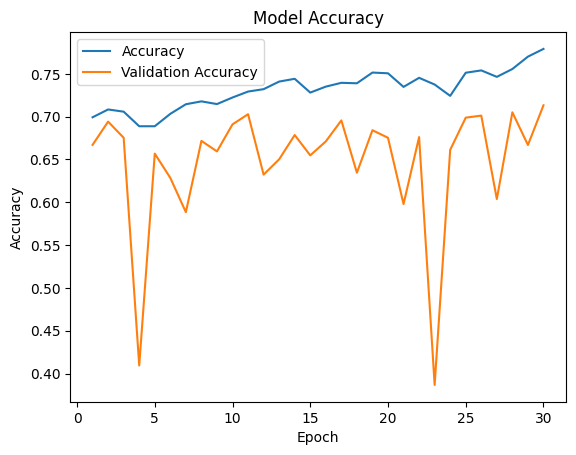

In [ ]:
#Plot the Training and Validation Accuracies for model3
list_ep = [i for i in range(1, 31)]
plt.plot(list_ep,history_5.history['accuracy'])
plt.plot(list_ep,history_5.history['val_accuracy'])
plt.title('Model Accuracy')
plt.ylabel('Accuracy')
plt.xlabel('Epoch')
plt.legend(['Accuracy', 'Validation Accuracy'], loc='upper left')
plt.show()

### **Evaluating the Model on Test Set**

In [ ]:
#for grayscale images
test_images3, test_labels3 = next(test_set2)
accuracy_complex = model3.evaluate(test_images3, test_labels3, verbose = 2)

4/4 - 0s - loss: 15.0871 - accuracy: 0.7188 - 298ms/epoch - 74ms/step


**Observations and Insights:__**
1. Here we have created a complex model architecture with five convolutional blocks. We have used relu activation, with batchnormalizations, droupouts, maxpooling layers along with adam optimizer with a learning rate of 0.001 loss='categorical_crossentropy', metrics equal to accuracy
2. Model appears to be overfitting as training accuracy is ~78% and validation accuracy is 71 %  
3. Testing accuracy is ~72%
4. Still this model has been failed to surpass the performance of base model in rgb color mode.
5. But this model performance is far better than transfer learning models.


# **Plotting the Confusion Matrix for the chosen final model**

4/4 [==============================] - 0s 3ms/step
              precision    recall  f1-score   support

           0       0.97      0.89      0.93        35
           1       0.69      0.67      0.68        33
           2       0.62      0.62      0.62        32
           3       0.84      0.96      0.90        28

    accuracy                           0.78       128
   macro avg       0.78      0.79      0.78       128
weighted avg       0.78      0.78      0.78       128



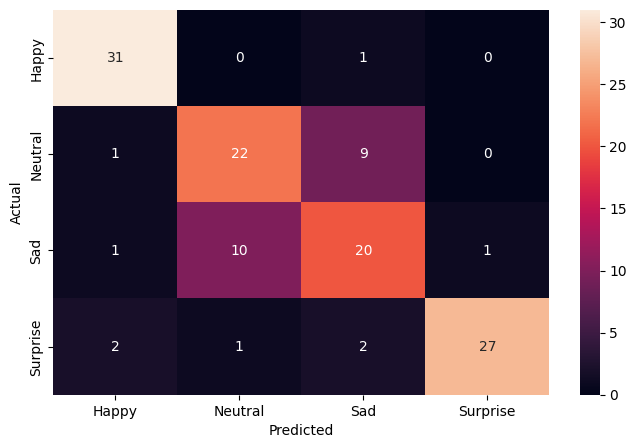

In [ ]:
#Ploting nthe confusion matrix for base CNN rgb model as it shows comparatively the best performance so far
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix



pred = model1_rgb.predict(test_images1_rgb)
pred = np.argmax(pred, axis = 1)
y_true = np.argmax(test_labels1_rgb, axis = 1)

# Printing the classification report
print(classification_report(pred, y_true))

# Plotting the heatmap using confusion matrix
cm = confusion_matrix(y_true, pred)
plt.figure(figsize = (8, 5))
sns.heatmap(cm, annot = True,  fmt = '.0f', xticklabels = ['Happy', 'Neutral', 'Sad', 'Surprise'], yticklabels = ['Happy', 'Neutral', 'Sad', 'Surprise'])
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

**Observations and Insights:__**
1. As observed from the confusion matrix there are very few misclassification by the model except for sad vs neutral.
2. The model is giving about 78% overall accuracy on the test data which is comparable to the accuracy of the validation data. This implies that the model is giving a generalized performance.
3. The recall has a high range which implies that the model is good at identifying some emotions while poor at identifying some other emotions. For example, the model can identify more than 96% of happy emotions but can identify only ~ 62% of sad emotions.
4. The model is majorly confused between neutral and sad emotions. This implies that the model might be focused on features related to shapes and sizes but not deep features of emotions that can help to distinguish between emotions like neutral and sad.
5. Consequently, precision also has a high range with the 'sad' class having the least precision.
6. The highest precision is for 'happy' which implies that the model can distinguish happy from other emotions with a 97% of precision.

# **Conclusion:____________**
1. This problem was to to find the most efficient and acuurate Deep Learning architecture that can classify facial emotion images into their four classes namely happy, neutral, sad and suprise.

2. Here we have created several models comprising of both grayscale and rgb color modes to identify whether there is any effect of color mode in model performance.

3. Further we have developed several CNN architectures in different levels of complexity as well as several transfer learning models to identify the best model which can be used to identify facial emotions.

4. Models I have developed can be summarised as Base and Second CNN model for both grayscale and rgb modes(4 models), Three Transfer leaning model architectures for rgb mode and one final complex CNN for grayscale mode. Apart from these 8 main models I have developed few more to identify how models going to predict results based on different learning rates, droupout rates, batchnormalization layers, Max pooling layes, fully connected dense layers and no of epochs.

5. We visualized a subset of each emotion and as humans we can clearly identify the emotion present in each face but the objective of this study was to develop a highly trained CNN model to identify unique features depicted in each image to distingush them among four classes.

6. The first architecture was a Convolutional Neural Network. We fit the same model for both grayscale and rgb color mode. The model shown overfitting. This model did quite well for rgb color mode giving training accuracy of 87% and validation accuracy of 71%. The test accuracies were somewhat similar in both rgb and grayscale color modes which was around 78-79%

7. The second model was another CNN with a slighly complex architecture again with both grayscale and rgb color modes. This model also shown overfitting and performed almost similar in both color modes but with a less accuracy than first architecture in terms of training, validation & testing.

8. In this second architecture we could observe some unusual behaviour which validation accuracy is higher than training accuracy in both rgb and grayscale color modes.


*     This might occure due to regularization techniques used such as dropout. These techniques introduce randomness and prevent the model from overfitting the training data.
*     Another possible reason is Model Complexity. If the model is very complex and prone to overfitting, it might fit the training data too closely, resulting in lower training accuracy but higher validation accuracy.

*     Further overlapping data or incorrect splits can lead to unexpected results.

9. Then we developed few transfer learning models. First was VGG16. That model showed a very poor performance as training accuracy dropped as 48% and validation accuracy as 54%. Then I made few alterations to the parameters of leaning rate and droupout rate to check for any performance improvement but it led to further poor model performance of training accuracy of 37%. Then again same VGG16 model slightly changed to a higher learning rate to check for any improvement but again the training accuracy did not exceed 48% which was initial value of VGG16 model. The later changes made to the model also was failed to improve the performance. In this architecture also we observed that validation accuracy is higher than training accuracy.

10. Then we trained the data using ResNet V2 Model which having around 44 million parameters. This model further decreased the performance as training accuracy of 38%, validation accuracy of 20% and testing accuracy of 25%. This model shown overfitting as there is a significance difference between training and validation accuracy. Model is not capable to generalizing learned features in unseen data in the validation set.

11. The final transfer learning model which was trained is EfficientNet Model which is having around 9 million trainable parameters. This model also shown further reduced performance of training accuracy of 26% , validation acciracy of 24% and test accuracy of 25%. This model also slightly overfit unseen data.

12. All the transfer learning models showed a poor behaviour and that might due to variuos reasons.


*   Data Mismatch: The pre-trained models used for transfer learning might have been trained on a dataset that significantly differs from our own dataset. In such cases, the features learned by the pre-trained model may not be relevant to this dataset.This can be addressed by using a pre-trained model that is more closely related to our domain of dataset.
*   Class Imbalance: Class imbalances in the dataset can negatively impact model performance. We can address this by implementing techniques to address class imbalance, such as class weighting, oversampling, or synthetic data generation. (Here I have tried to calculate class weights but it took very long time to execute hense I ignored finding class weights)

*   Inadequate Data Augmentation: We might not have applied appropriate data augmentation techniques, the model may not generalize well to new samples because data augmentation is crucial for increasing dataset diversity.

*   Layer Selection: The specific layer that i have used for feature extraction in the pre-trained model may not be suitable for the task. Some layers capture higher-level features that may not align with the dataset.

*   Insufficient Training Data
*   Pre-processing such as normalization and resizing, have not matched the requirements of the pre-trained model
*   Model Complexity: If the pre-trained model is too complex for the dataset, it may lead to overfitting.

13. Further we have not trained any of the layers in above transfer learning models but we have used their pre-trained weights and biases.To overcome this poor performance we can build our own architecture on top of each models' Transfer layers to see whether performance increases.

14. Finally we trained a complex CNN for grayscale color mode and that gave somewhat satisfactory performance but less than the base model. The training accuracy was 77% and testing accuracy was 71%. Model shown overfitting. Both validation and training accuracy has improved in comparison to transfer learning models.

15. We should consider both accuracy and efficiency, We should consider computation time because when this model will be implemented in the real world, we would expect it to be super fast, besides being super accurate. As the model complexity increases execution time also increased. In this study the simplest model gave the best performance, hense we can conclude that the selected model is both efficient and accurate.







### **Insights**

### **Refined insights**:
- What are the most meaningful insights from the data relevant to the problem?

For this particular dataset, simple models gave higher accuracy. By nature simple models take less computation time, therefore the ***Base CNN model in rgb color mode can be considered as the best ***model to predcit facial emotions.
As the model complexity increases model performce decreased. This may due to the data set imbalance, diversity and comparatevely small in size compared to model complexity.

### **Comparison of various techniques and their relative performance**:
- How do different techniques perform? Which one is performing relatively better? Is there scope to improve the performance further?

**Simple CNN model performed relatively better than second (slightly complex) and final complex CNN models. In the selected best Base CNN we can observe that validation accuracy was not increased significantly after around 10 epochs. This may due to insufficient validation data as the model is unable to generalize due to less variability of data in the validation set.We can pay more attention to the validation set in order to increase performance in this case.**

**The other point is poor performance of transfer learning models. This can be further enhanced by again paying attention to the training and validation data. We have used models having millions of parameters but our dataset was only few thousands of data. We can consider feeding more appropriate size of data to these complex models. Further we have used pre-trained weights and biases of those models, in order to improve the performance we can built few trainable layers on top of these architectures and check for an increased performance.**

### **Proposal for the final solution design**:
- What model do you propose to be adopted? Why is this the best solution to adopt?

**Base CNN model shown the best performance as it is training , validation and testing accuracies are comparatively high as well as due to model simplicity computation cost will be minimum.**

# **Final Report**

---



# **Executive summary**


In this capstone project on deep learning models suggest a Convolutional Neural Network Model to classify grayscale images consisitng of faces of men, women, kids and babies into four categories namely Happy, Sad, Neutral and Surprise based on their facial expressions. The image classification based on facial emotions has been trained on different CNN architectures built on different complexities as well as several transfer leaning models. The model performces varied based on their complexity as well as the color mode of images used. Suprisingly transfer learning models showed an extremely poor performace over the selected images. The best model classified the images into four classes was the simple base CNN model trained with RGB color mode with a 78% of testing accuracy. However the suggested model performed well with observed data and low error. But it is recommended to finetune this selected model before using as the developed model is overfitting. There are few limitations including imbalance of data among four classes as the suprise class had little less number of images compared to other as well as imbalance of images among men, women, kids and babies across different classes. Further it is not tested for original color images as the data set is consisting of black and white images (Evethough the colormode set to rgb at the loading phase). To improve the performance some preprocessing is done to images in terms of flipping, normalizing, barightness change and shear change but it is recommended to run the model over images collected from different lighting conditions as in the real world models will be receiving data taken of different lighting conditions.

# **Problem Summary**

Facial emotion detection is an important topic in the fields of computer vision and artificial intelligence owing to its significant academic and commercial potential.It plays a crucial role in understanding human behavior, improving human-computer interactions, enhancing healthcare and mental health services, and benefiting various industries and domains where emotions play a significant role. It has the potential to contribute to more empathetic, efficient, and personalized solutions in a wide range of applications such as Virtual Reality (VR) and Augmented Reality (AR), Advanced driver assistant systems (ADASs),Gaming and Entertainment, Autism Spectrum Disorder (ASD) Diagnosis, telemedicine and virtual therapy sessions and in applications detects a user is frustrated or anxious or tired etc.Therefore, identifying facial emotions accurately is very important to the development of machines with AI capabilities.

The goal is to accurately predict facial impotions using deep learning techniques. In this project, we have built a multi-class classification algorithm on images of facial expressions to predict the Facial Emotions (Happy, Sad, Neutral and Surprise) using Convolutional Neural Networks and Transfer Learning.

#**Solution Design**

The problem solving approach consistinng of three major steps.
1. Base & Second CNN model Development
2. Use of Transfer Learning Models
3. Complex CNN Model Development.

Original images of the dataset appeared in Balck and White colors but the developed models were trained using both color modes of Grayscale and rgb. As we are going to develop an accurate model for image classification, we selected Convolution Neural Network as it follows specialized techniques to process images.

The Base model was developed as a simple and a small-sized model with four convolutional layers and maxpooling layers after each with relu activation and with one fully connected layer with 512 neurons and used Adam optimizer with 0.001 learning rate. The model could successfully classify images with overall 78% of accuracy in RGB color mode. This was the best model out of all and Figure 1 shows the accuracy of the model for training and validation data.

**Figure1: Best ovearll model Accuracy**
![picture](https://drive.google.com/uc?export=view&id=1cqyPWKkZIgd0OlPBIRCxOc620caoTDYW)











Base CNN for RGB color mode was able to classify images of Happy emotion and Surprise emotion with a strong performance. On average  93% happy images and 90% of surprise images classified correctly. But it is majorly confused between Neutral and Sad emotions having around 62% to 67% of accuracy respectively. Overall the model performs well with the given dataset with a 87% training accuracy and 71% validation accuracy.

It is very important to pay attention to the validation dataset as there is class imbalance present and it directly affect the model performance. Further models inability to generalize for unseen data should be addressed as there is a significant difference between training and validation accuracy.

As the transfer learning models we have used VGG16, ResNet V2 and EfficientNet. Use of transfer learning models didn't give expected results. The poor behaviour of the model can be explained in various points such as Data Mismatch, Class Imbalance, Model Complexity, Insufficient training data, the size of the validation set is not big enough, Imbalanced data in the validation set and High regularization. Overall Transfer learning Architectures are showing a very poor performance for this dataset. It is impossible to satify with the accuracies we received as they are unable to reach at least 50% when it come to training accuracy. That means not even half of the dataset is correctly classified by these transfer learning models. We have not trained any of the layers in above transfer learning models but we have used their pre-trained weights and biases.To overcome this poor performance we can build our own architecture on top of each models' Transfer layers to see whether performance increases.

Finally the complex CNN architecture also failed to surpass the performance of base model in rgb color mode but perform better than all the transfer learning models used in this work. Again it proves that model complexity adversely affect the performance.

#**Analysis & Key Insights**

When compared to existing image classification models our model performce is somewhat acceptable. State-of-the-art models can achieve accuracy levels well above 90%. Eventhough this accuracy is acceptable in the application areas of entertainment or basic sentiment analysis, it is not recommended for critical applications such as healthcare and security where high level of accuracy is required. The attention to dataset is very important as its size is significantly small compared to complexity of models including transfer learning models models that we have developed. Data variability and imbalance could be the main reason for poor performance of complex models. Figure 2 shows the Top 5 accurate models on ImageNet to give us the understanding of current state in the image classification models.

**Figuer 2: Top 5 Image Classification Models on ImageNet**

![picture](https://drive.google.com/uc?export=view&id=10k5uPXYPHo9j0xgBWNRXs-UoH2PXuW4h)

For this particular dataset, simple models gave higher accuracy. As the model complexity increases model performance decreased. Even the best performing model shown overfitting, to overcome it is recommended to try several data augmentation more suitable for the dataset such as random rotations, translations, flips, and zooms, conduct Hyperparameter Tuning, Implement early stopping, Further reduce Model Complexity by reducing the number of convolutional layers and filters as well as Apply Regularization Techniques.



# **Recommendations for implementation**


Solution model must be further improved as it  learns to perform well on the training data but fails to generalize to unseen data.It is important to address the class imbalance of the dataset as well as the size of the dataset. More variability in the data will lead to a better performance when it come to transfer learning models which are having higher accuracies above 90% in real world. Model is tested only for original black and white images, hence it is recommended to run the model over images collected from different lighting conditions. To overcome  poor performance of Transfer Learning models  it is recommended to build own architecture on top of each models' Transfer layers.

As the model complexity increases execution time also increased hense we can conclude that the selected model is both efficient and accurate. Due to the simplicity of the solution model cost will be minimum when it come to impelemntation. As an estimation infrastructure cost will be minimum as $8-10/month as 1vCPU & 1GB RAM will be adequate. Data Transfer costs, Storage costs, Software costs will be minimum as per the use. Significant amount will be required to personnel costs and maintenance as salaries of DevOps engineers, data scientists, or ML engineers are comparatevily high in the industry. Apart from them Scaling and Redundancy, Maintenance and Support and Security Costs will be charges as per the use. It is impossible to provide any complete cost analysis but with above information, implementation of the solution model will be comparatevely low due to its small size.

It is recommended to finetune the model as explained above before implementation as the accuracy is not acceptable in some application areas. Finally our model is not strong enough to compete with exisiting large models but for the given dataset it shows a satisfactory performance.
